records=197 unique_subjects=197


/tmp/ipykernel_263380/4166867544.py:193: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_263380/4166867544.py:193: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_263380/4166867544.py:193: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_263380/4166867544.py:193: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_263380/4166867544.py:193: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw

loaded_samples=3 failures=0


,subject_id,signal_length,duration_minutes,sample_rate,EEG Fpz-Cz_mean,EEG Fpz-Cz_std,EEG Fpz-Cz_min,EEG Fpz-Cz_max,EEG Pz-Oz_mean,EEG Pz-Oz_std,EEG Pz-Oz_min,EEG Pz-Oz_max,EMG_mean,EMG_std,EMG_min,EMG_max
0,SC4001,7950000,1325.0,100.0,-2.523991e-18,0.999614,-7.413969,6.576325,-1.108268e-18,0.999126,-14.929733,17.169476,1.757212e-16,0.989658,-3.577237,0.993738
1,SC4002,8490000,1415.0,100.0,-5.624084e-19,0.999656,-7.182917,7.171203,5.423224e-18,0.999204,-16.006680,14.077389,-8.227231e-17,0.993348,-4.731203,1.736953
2,SC4011,8406000,1401.0,100.0,5.761431e-18,0.999637,-7.405427,7.397975,1.741954e-17,0.999128,-11.069552,11.080704,2.215852e-16,0.991175,-2.435550,1.239501


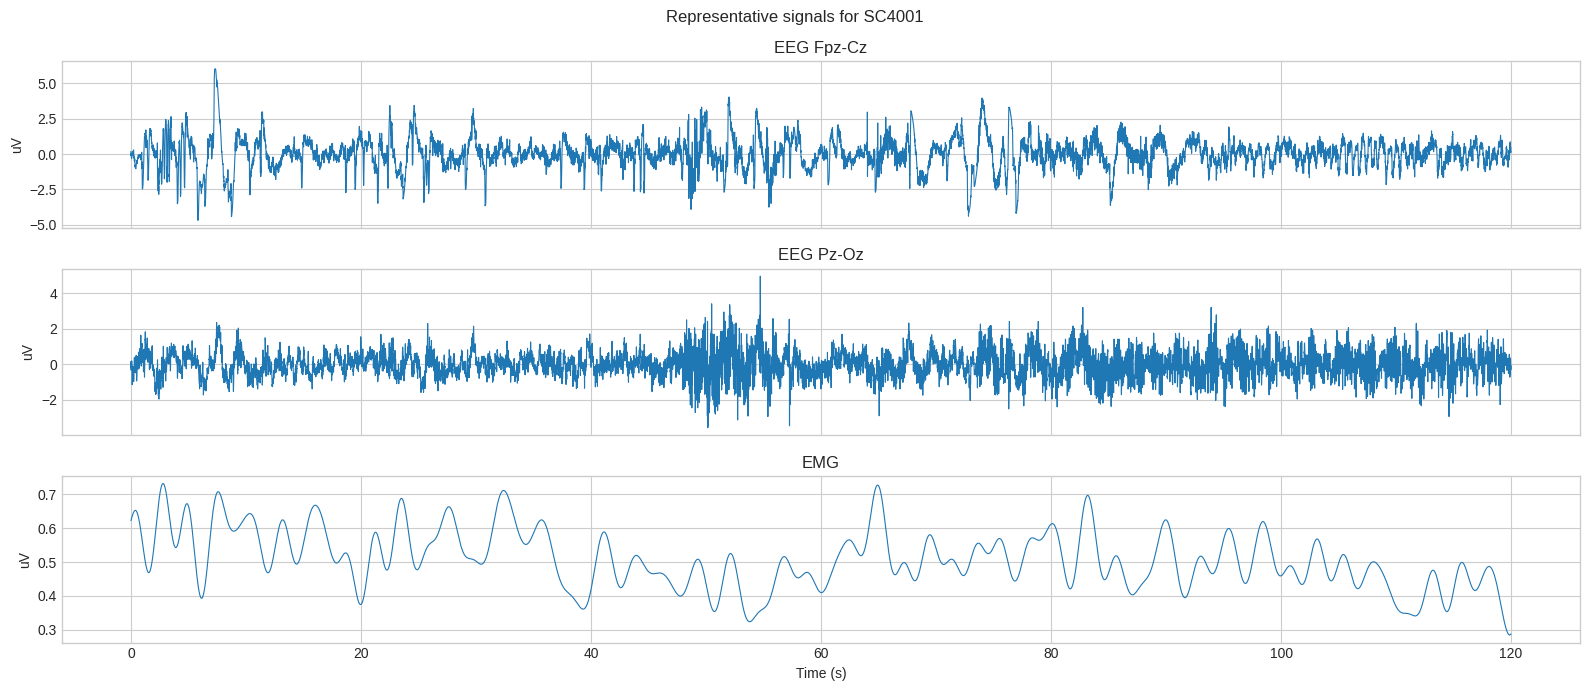

train_subjects=2 test_subjects=1
train_examples=2 test_examples=1
train_windows=5632 test_windows=2650
ResNet1D(
  (stem): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from time import monotonic
import random
import re
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

DATA_ROOT = Path("/home/gella.saikrishna/sleep-edf-database-expanded-1.0.0/sleep-edf-database-expanded-1.0.0")
PSG_DIR = DATA_ROOT / "sleep-cassette"
RECORDS_PATH = DATA_ROOT / "RECORDS"
RANDOM_STATE = 42
TARGET_CHANNELS = ["EEG Fpz-Cz", "EEG Pz-Oz", "EMG"]
CHANNEL_ALIASES = {
    "EEG Fpz-Cz": ["EEG Fpz-Cz", "EEG Fpz-Cz", "EEG Fpz-Cz-Pz-Oz", "EEG FPZ-CZ", "EEG Fpz-Cz"],
    "EEG Pz-Oz": ["EEG Pz-Oz", "EEG PZ-OZ", "EEG Pz-Oz"],
    "EMG": ["EMG", "EMG submental", "EMG Chin", "EMG"],
}
STAGE_MAP = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3,
    "Sleep stage R": 4,
    "Sleep stage ?": -1,
    "Movement time": -1,
}


@dataclass
class SubjectSample:
    subject_id: str
    psg_path: Path
    hypnogram_path: Path
    signal: np.ndarray
    times: np.ndarray
    sample_rate: float
    stages: np.ndarray | None


class SleepEDFWindowDataset(Dataset):
    def __init__(self, samples, window_size_seconds: int = 30, step_size_seconds: int = 30):
        self.examples = []
        self.labels = []
        self.subject_ids = []
        for sample in samples:
            if sample.signal.shape[0] != len(TARGET_CHANNELS):
                continue
            window_size = int(window_size_seconds * sample.sample_rate)
            step_size = int(step_size_seconds * sample.sample_rate)
            total_length = sample.signal.shape[-1]
            for start in range(0, max(total_length - window_size + 1, 0), step_size):
                window = sample.signal[:, start:start + window_size]
                if window.shape[-1] != window_size:
                    continue
                label = 0
                if sample.stages is not None and len(sample.stages) > 0:
                    stage_index = min(start // max(step_size, 1), len(sample.stages) - 1)
                    label = int(sample.stages[stage_index]) if sample.stages[stage_index] >= 0 else 0
                self.examples.append(torch.tensor(window, dtype=torch.float32))
                self.labels.append(torch.tensor(label, dtype=torch.long))
                self.subject_ids.append(sample.subject_id)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        return self.examples[index], self.labels[index]


class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class ResNet1D(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = nn.Sequential(ResidualBlock1D(32, 32), ResidualBlock1D(32, 32))
        self.layer2 = nn.Sequential(ResidualBlock1D(32, 64, stride=2), ResidualBlock1D(64, 64))
        self.layer3 = nn.Sequential(ResidualBlock1D(64, 128, stride=2), ResidualBlock1D(128, 128))
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)


def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def read_records(records_path: Path = RECORDS_PATH):
    return [line.strip() for line in records_path.read_text().splitlines() if line.strip()]


def get_subject_id(record_line: str):
    return Path(record_line).stem.replace("-PSG", "")[:6]


def build_hypnogram_path(psg_path: Path):
    return psg_path.with_name(psg_path.name.replace("-PSG.edf", "-Hypnogram.edf"))


def resolve_channel_names(raw: mne.io.BaseRaw, requested_channels=None):
    requested_channels = requested_channels or TARGET_CHANNELS
    available = {channel.lower(): channel for channel in raw.ch_names}
    resolved = {}
    for target in requested_channels:
        candidates = CHANNEL_ALIASES.get(target, [target])
        match = None
        for candidate in candidates:
            candidate_key = candidate.lower()
            if candidate_key in available:
                match = available[candidate_key]
                break
            for source_name in raw.ch_names:
                if candidate_key in source_name.lower():
                    match = source_name
                    break
            if match is not None:
                break
        resolved[target] = match
    return resolved


def read_sleep_stages(hypnogram_path: Path):
    if not hypnogram_path.exists():
        return None
    try:
        annotations = mne.read_annotations(hypnogram_path)
    except Exception:
        return None
    labels = []
    for description in annotations.description:
        if description in STAGE_MAP:
            labels.append(STAGE_MAP[description])
        else:
            labels.append(-1)
    return np.asarray(labels, dtype=int) if labels else None


def load_subject_sample(record_line: str):
    psg_path = PSG_DIR / Path(record_line).name
    hypnogram_path = build_hypnogram_path(psg_path)
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    channel_map = resolve_channel_names(raw)
    missing = [target for target, actual in channel_map.items() if actual is None]
    if missing:
        raise ValueError(f"Missing channels in {psg_path.name}: {missing}")
    selected = raw.copy().pick([channel_map[channel] for channel in TARGET_CHANNELS])
    signal = selected.get_data()
    # Per-participant normalization across the entire recording (channel-wise z-score)
    eps = 1e-8
    channel_means = np.mean(signal, axis=1, keepdims=True)
    channel_stds = np.std(signal, axis=1, keepdims=True)
    signal = (signal - channel_means) / (channel_stds + eps)
    times = selected.times
    sample_rate = float(selected.info['sfreq'])
    stages = read_sleep_stages(hypnogram_path)
    subject_id = get_subject_id(record_line)
    return SubjectSample(subject_id, psg_path, hypnogram_path, signal, times, sample_rate, stages)


def load_all_subjects(records=None, limit=None):
    records = records or read_records()
    samples = []
    failures = []
    for index, record_line in enumerate(records):
        if limit is not None and index >= limit:
            break
        try:
            samples.append(load_subject_sample(record_line))
        except Exception as exc:
            failures.append((record_line, str(exc)))
    return samples, failures


def summarize_samples(samples):
    rows = []
    for sample in samples:
        row = {
            "subject_id": sample.subject_id,
            "signal_length": sample.signal.shape[-1],
            "duration_minutes": sample.signal.shape[-1] / (sample.sample_rate * 60.0),
            "sample_rate": sample.sample_rate,
        }
        for channel_index, channel_name in enumerate(TARGET_CHANNELS):
            channel_values = sample.signal[channel_index]
            row[f"{channel_name}_mean"] = float(np.mean(channel_values))
            row[f"{channel_name}_std"] = float(np.std(channel_values))
            row[f"{channel_name}_min"] = float(np.min(channel_values))
            row[f"{channel_name}_max"] = float(np.max(channel_values))
        rows.append(row)
    return pd.DataFrame(rows)


def plot_one_subject(sample: SubjectSample, seconds: int = 120):
    max_samples = int(seconds * sample.sample_rate)
    view = sample.signal[:, :max_samples]
    time_axis = np.arange(view.shape[-1]) / sample.sample_rate
    fig, axes = plt.subplots(len(TARGET_CHANNELS), 1, figsize=(16, 7), sharex=True)
    for axis, channel_name, values in zip(axes, TARGET_CHANNELS, view):
        axis.plot(time_axis, values, linewidth=0.8)
        axis.set_title(channel_name)
        axis.set_ylabel("uV")
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Representative signals for {sample.subject_id}")
    plt.tight_layout()
    plt.show()


def subject_level_split(samples, test_size: float = 0.2, seed: int = RANDOM_STATE):
    subject_ids = sorted({sample.subject_id for sample in samples})
    train_ids, test_ids = train_test_split(subject_ids, test_size=test_size, random_state=seed, shuffle=True)
    train_samples = [sample for sample in samples if sample.subject_id in set(train_ids)]
    test_samples = [sample for sample in samples if sample.subject_id in set(test_ids)]
    return train_ids, test_ids, train_samples, test_samples


def train_resnet(model, train_loader, epochs: int = 3, device: str | None = None, log_every_seconds: int = 90):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    last_log_time = monotonic()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for step, (batch_x, batch_y) in enumerate(train_loader, start=1):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.item())
            current_time = monotonic()
            if current_time - last_log_time >= log_every_seconds:
                avg_loss = running_loss / max(step, 1)
                print(f"epoch={epoch} step={step} running_loss={avg_loss:.4f}")
                last_log_time = current_time
        print(f"epoch={epoch} epoch_loss={running_loss / max(step, 1):.4f}")
    return model


set_seed()
records = read_records()
subject_ids = sorted({get_subject_id(record) for record in records})
print(f"records={len(records)} unique_subjects={len(subject_ids)}")

samples, failures = load_all_subjects(limit=min(3, len(records)))
print(f"loaded_samples={len(samples)} failures={len(failures)}")
if failures:
    print("sample_failures:")
    for record_line, error_message in failures[:3]:
        print(record_line, error_message)

if samples:
    stats_df = summarize_samples(samples)
    display(stats_df)
    plot_one_subject(samples[0], seconds=120)
    train_ids, test_ids, train_samples, test_samples = subject_level_split(samples)
    print(f"train_subjects={len(train_ids)} test_subjects={len(test_ids)}")
    print(f"train_examples={len(train_samples)} test_examples={len(test_samples)}")
    train_dataset = SleepEDFWindowDataset(train_samples)
    test_dataset = SleepEDFWindowDataset(test_samples)
    print(f"train_windows={len(train_dataset)} test_windows={len(test_dataset)}")
    model = ResNet1D(in_channels=len(TARGET_CHANNELS), num_classes=5)
    print(model)


In [2]:
records = read_records()
samples, failures = load_all_subjects(records)
print(f"records={len(records)} loaded_samples={len(samples)} failures={len(failures)}")
if failures:
    print("failures=")
    for record_line, error_message in failures[:5]:
        print(record_line, error_message)

stats_df = summarize_samples(samples)
display(stats_df[["subject_id", "signal_length", "duration_minutes", "sample_rate"]].head())
display(stats_df.describe().T)

if samples:
    plot_one_subject(samples[0], seconds=120)

train_ids, test_ids, train_samples, test_samples = subject_level_split(samples)
print(f"train_subjects={len(train_ids)} test_subjects={len(test_ids)}")
print(f"train_samples={len(train_samples)} test_samples={len(test_samples)}")

train_dataset = SleepEDFWindowDataset(train_samples)
test_dataset = SleepEDFWindowDataset(test_samples)
print(f"train_windows={len(train_dataset)} test_windows={len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, drop_last=False)

if len(train_dataset) > 0:
    model = ResNet1D(in_channels=len(TARGET_CHANNELS), num_classes=5)
    trained_model = train_resnet(model, train_loader, epochs=2, log_every_seconds=90)
    print(trained_model.__class__.__name__)


/tmp/ipykernel_261798/130611481.py:193: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_261798/130611481.py:193: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_261798/130611481.py:193: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_261798/130611481.py:193: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_261798/130611481.py:193: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mn

KeyboardInterrupt: 

In [1]:
import os, socket
print(f"Running on: {socket.gethostname()}")
print(f"SSH Connection: {'YES (Remote)' if 'SSH_CONNECTION' in os.environ else 'NO (Local)'}")
print(f"Python path: {__import__('sys').executable}")

Running on: LAPTOP-J4R1BQ1A
SSH Connection: NO (Local)
Python path: c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe
